# SPA613M Programming Assignment

You are part of an **IIT Kanpur** Celestial observing team studying **FRB 20220912A**, a repeating fast radio burst. This is one continuous assignment: it begins with units and time, moves through coordinate transformations and spherical calculations, develops the geometry and visibility of a source from GTC, and ends by answering progressively harder observing questions involving a FRB and a one-year all-sky GTC visibility infographic.

Use **UTC internally** for astronomical calculations. Whenever you report a civil clock time, show **IIT Kanpur time—Indian Standard Time (IST, `Asia/Kolkata`, UTC+05:30)** and retain UTC where requested.

**Total: 40 marks**  
**Optional:** Q20 carries 2 bonus marks.


## Marking Scheme

| Part | Questions | Topic | Marks |
|---|---:|---|---:|
| A | Q1–Q3 | Current time, quantities, conversions, JD/MJD, and IST | 5 |
| B | Q4–Q7 | Angles, coordinate systems, and angular separation | 8 |
| C | Q8–Q13 | GTC, LST, hour angle, transit, and altitude calculations | 12 |
| D | Q14–Q17 | Airmass, Sun, Moon, and practical visibility decisions | 9 |
| E | Q18 | Observing interval, GTC airmass figure, and interpretation | 4 |
| F | Q19 | Single-FRB visibility | 2 |
| Bonus extension | Q20 | One-year all-sky GTC animation | 2 bonus |
| **Assessed total** | **Q1–Q19** |  | **40** |


## Fixed target record

FRB 20220912A is a repeating fast radio burst. Use the following published VLBI position throughout the assignment:

- Source: `FRB 20220912A`
- ICRS/J2000 RA: `23h09m04.8989s`
- ICRS/J2000 Dec: `+48d42m23.9078s`
- Coordinate uncertainty: `5 mas`
- Dispersion measure: $219.46\,\mathrm{pc\,cm^{-3}}$
- Host redshift: $0.0771$

Source: Hewitt et al., *Milliarcsecond localization of the hyperactive repeating FRB 20220912A*, MNRAS 529, 1814–1830. The values above are frozen, so no catalogue or web query is required. [Published article](https://academic.oup.com/mnras/article/529/2/1814/7623035)

## Fixed GTC observing case

| Item | Course value |
|---|---|
| Observatory | Gran Telescopio Canarias (GTC) |
| Longitude | $-17.889^\circ$ |
| Latitude | $+28.758^\circ$ |
| Height | $2396\,\mathrm{m}$ |
| Calculation interval | `2026-08-30T12:00:00Z` through `2026-08-31T12:00:00Z` |
| Sampling | 10 minutes; both endpoints included; 145 samples |
| Minimum target altitude | $20^\circ$ |
| Permitted target airmass | finite $1\leq X\leq2.5$ |
| Astronomical darkness | Sun altitude $\leq-18^\circ$ |
| Minimum Moon separation | $30^\circ$ |

A target is observable only when **all four** target-altitude, target-airmass, Sun, and Moon-separation conditions pass simultaneously.

## Setup

Run the dependency cell before Q1. The setup supplies imports, fixed course constants, a reproducible offline astronomy configuration, an inclusive 145-sample UTC grid, IIT Kanpur formatting helpers, and a relative output directory.

In [24]:
import subprocess
import sys

REQUIRED_PACKAGES = [
    "numpy>=1.26",
    "matplotlib>=3.8",
    "astropy>=6.0",
    "astropy-iers-data",
    "tzdata",
    "healpy>=1.18",
    "astroplan>=0.10",
    "imageio>=2.31",
]

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--disable-pip-version-check",
        *REQUIRED_PACKAGES,
    ]
)
print("Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.")

Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.


In [25]:
from datetime import timezone
from pathlib import Path
from zoneinfo import ZoneInfo

import astropy
import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import healpy as hp
import numpy as np
from astropy import units as u
from astropy.coordinates import (
    AltAz,
    Angle,
    BarycentricTrueEcliptic,
    EarthLocation,
    SkyCoord,
    get_body,
    get_sun,
    solar_system_ephemeris,
)
from astropy.time import Time
from astropy.utils import iers
from astroplan import Observer

# Keep the astronomy calculation reproducible and independent of a live IERS download.
iers.conf.auto_download = False
iers.conf.auto_max_age = None

IITK_TIMEZONE = ZoneInfo("Asia/Kolkata")

FRB_NAME = "FRB 20220912A"
FRB_RA_J2000 = "23h09m04.8989s"
FRB_DEC_J2000 = "+48d42m23.9078s"
EARLIER_POSITION_RA = "23h09m04.9s"
EARLIER_POSITION_DEC = "+48d42m25.4s"

START_UTC = "2026-08-30T12:00:00"
STOP_UTC = "2026-08-31T12:00:00"
STEP_MINUTES = 10

GTC_LONGITUDE_DEG = -17.889
GTC_LATITUDE_DEG = 28.758
GTC_HEIGHT_M = 2396.0

MIN_TARGET_ALTITUDE_DEG = 20.0
MAX_AIRMASS = 2.5
MAX_SUN_ALTITUDE_DEG = -18.0
MIN_MOON_SEPARATION_DEG = 30.0

OUTPUT_DIR = Path("assignment_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# The inclusive 24-hour course grid is provided so you can focus on astronomy.
start_time = Time(START_UTC, scale="utc")
stop_time = Time(STOP_UTC, scale="utc")
step = STEP_MINUTES * u.min
number_of_steps = int(
    np.round(((stop_time - start_time) / step).to_value(u.dimensionless_unscaled))
)
times = start_time + np.arange(number_of_steps + 1) * step
assert len(times) == 145

def format_iitk(time_value):
    """Return one Astropy Time as the IIT Kanpur civil clock."""
    return time_value.to_datetime(timezone=IITK_TIMEZONE).strftime(
        "%Y-%m-%d %H:%M:%S IST"
    )

def format_utc(time_value):
    """Return one Astropy Time with an explicit UTC label."""
    return time_value.utc.strftime("%Y-%m-%d %H:%M:%S UTC")

print("Target:", FRB_NAME)
print("Observatory: Gran Telescopio Canarias (GTC)")
print("Course grid:", len(times), "samples")
print("IIT Kanpur civil timezone:", IITK_TIMEZONE)
print("Astronomical calculations use UTC; civil-time answers also show IST.")

Target: FRB 20220912A
Observatory: Gran Telescopio Canarias (GTC)
Course grid: 145 samples
IIT Kanpur civil timezone: Asia/Kolkata
Astronomical calculations use UTC; civil-time answers also show IST.


# Part A.  Astropy foundations: time, units, and conversions (5 marks)

## Q1. Current UTC and IIT Kanpur time [1 mark]

Call `Time.now()` exactly once and store it as `now`. Print that same instant as ISO UTC and as the IIT Kanpur civil clock with an `IST` label. In one sentence, explain why two separate calls to `Time.now()` need not describe exactly the same instant.

In [26]:
# YOUR ANSWER:

from astropy.time import Time
now = Time.now()

print(" Current timings:\n ISO UTC:", now.iso, "\n IIT Kanpur Civil Clock Time:", format_iitk(now))

print("\n Required Explanation: \n Time.now() gives the exact time in milliseconds the moment that line of the code is executed, \n but the other 2 commands used might return slightly different times because there is usually \n a very minute delay between the running to 2 commands.")

# Write and run your code here. Add a Markdown cell below when an explanation is requested.

 Current timings:
 ISO UTC: 2026-09-06 17:04:19.834 
 IIT Kanpur Civil Clock Time: 2026-09-06 22:34:19 IST

 Required Explanation: 
 Time.now() gives the exact time in milliseconds the moment that line of the code is executed, 
 but the other 2 commands used might return slightly different times because there is usually 
 a very minute delay between the running to 2 commands.


Explanation: Time.now() gives the exact time in milliseconds the moment that line of the code is executed, but the other 2 commands used might return slightly different times because there is usually a very minute delay between the running the 2 commands.

## Q2. Physical quantities and unit conversions [2 marks]

Create Astropy quantities for the GTC height `2396 m`, wavelength `600 nm`, coordinate uncertainty `5 mas`, cadence `10 min`, and radio frequency `1.4 GHz`. Convert them respectively to kilometres, frequency in THz using `u.spectral()`, arcseconds, hours, and wavelength in centimetres using `u.spectral()`. Print every original value beside its converted value.

In [48]:
# YOUR ANSWER:

from astropy import units as u
h = 2396 * u.m          # GTC height parameter
w = 600 * u.nm          # Wavelength parameter
e = 5 * u.mas           # Co-ordinate Uncertainty in milli-arcseconds
c = 10 * u.min          # Cadence parameter
f = 1.4 * u.GHz         # Radio frequency parameter in GHz

# Now, converting these to the required units gives: (the _1 implies converted parameters)

h_1 = h.to(u.km)
w_1 = w.to(u.THz, equivalencies=u.spectral())      # Wavelength to freq in THz
e_1 = e.to(u.arcsecond)
c_1 = c.to(u.hr)
f_1 = f.to(u.cm, equivalencies=u.spectral())       # Frequency to wavelength in cm

# Grouping items sequentially for proper printing
labels = ["GTC Height", "Wavelength to Freq", "Co-ordinate Uncertainty", "Cadence", "Frequency to Wavelength"]
list_1 = [h, w, e, c, f]
list_2 = [h_1, w_1, e_1, c_1, f_1]

# Printing
print(f"{'Parameter Name':<30} {'Converted Values':<25} {'Original Values':<25}")
print("-" * 80)
for label, original, converted in zip(labels, list_1, list_2):
    print(f"{label:<30} {str(converted):<25} {str(original):<25}")

# Write and run your code here. Add a Markdown cell below when an explanation is requested.

Parameter Name                 Converted Values          Original Values          
--------------------------------------------------------------------------------
GTC Height                     2.396 km                  2396.0 m                 
Wavelength to Freq             499.6540966666666 THz     600.0 nm                 
Co-ordinate Uncertainty        0.005 arcsec              5.0 mas                  
Cadence                        0.16666666666666666 h     10.0 min                 
Frequency to Wavelength        21.413747 cm              1.4 GHz                  


## Q3. UTC, JD, MJD, IST, and time arithmetic [2 marks]

Construct `planning_start = Time(START_UTC, scale="utc")`. Print UTC, Julian Date, Modified Julian Date, and IIT Kanpur time. Add `2.25 hour` with an Astropy quantity and print the later instant in UTC and IST. Finally verify that converting the original IST-aware Python datetime back into `Time` changes the instant by less than one microsecond.

In [28]:
# YOUR ANSWER:

planning_start = Time(START_UTC, scale="utc")

print("UTC:", planning_start.iso)
print("JD:", planning_start.jd)
print("MJD:", planning_start.mjd)
print("IIT Kanpur:", format_iitk(planning_start))

later = planning_start + 2.25 * u.hour
print("Later UTC:", format_utc(later))
print("Later IST:", format_iitk(later))

# round-trip check
ist_dt = planning_start.to_datetime(timezone=IITK_TIMEZONE)   # IST-aware python datetime
roundtrip = Time(ist_dt)                                       # converting back
diff_microseconds = abs((roundtrip - planning_start).sec) * 1e6
print("Round-trip difference (microseconds):", diff_microseconds)
assert diff_microseconds < 1

print ("\nPart A Done")

# Write and run your code here. Add a Markdown cell below when an explanation is requested.

UTC: 2026-08-30 12:00:00.000
JD: 2461283.0
MJD: 61282.5
IIT Kanpur: 2026-08-30 17:30:00 IST
Later UTC: 2026-08-30 14:15:00 UTC
Later IST: 2026-08-30 19:45:00 IST
Round-trip difference (microseconds): 0.0

Part A Done


# Part B. Angles and coordinate transformations (8 marks)


## Q4. Parse angles and construct an ICRS coordinate [2 marks]

Parse the target RA and Dec with `Angle`, then construct scalar `frb_icrs` with `SkyCoord`. Print RA and Dec in decimal degrees and padded sexagesimal notation. Verify RA $347.2704120833^\circ$ and Dec $+48.7066410556^\circ$ within $10^{-8}$ degree. Explain why RA commonly uses hours while Dec uses degrees.

In [29]:
# YOUR ANSWER:

frb_ra = Angle(FRB_RA_J2000)
frb_dec = Angle(FRB_DEC_J2000)
frb_icrs = SkyCoord(ra=frb_ra, dec=frb_dec, frame="icrs")

print("RA (deg):", frb_icrs.ra.deg)
print("Dec (deg):", frb_icrs.dec.deg)
print("RA (sexagesimal):", frb_icrs.ra.to_string(unit=u.hour, sep=":", pad=True, precision=4))
print("Dec (sexagesimal):", frb_icrs.dec.to_string(unit=u.deg, sep=":", pad=True, precision=4, alwayssign=True))

assert abs(frb_icrs.ra.deg - 347.2704120833) < 1e-8
assert abs(frb_icrs.dec.deg - 48.7066410556) < 1e-8

# Write and run your code here. Add a Markdown cell below when an explanation is requested.

RA (deg): 347.27041208333327
Dec (deg): 48.70664105555556
RA (sexagesimal): 23:09:04.8989
Dec (sexagesimal): +48:42:23.9078


Explanation: RA is usually in hours because it tracks the Earth's rotation, and 24 hours = 360 degrees, so RA directly tells about the time delay until a source transits relative to another. Dec has no rotational meaning, so it's expressed as a plain angle (like latitude on Earth).

## Q5. ICRS to Galactic and back [2 marks]

Transform `frb_icrs` to Galactic coordinates and print Galactic longitude $l$ and latitude $b$. Transform the result back to ICRS, calculate the round-trip separation in microarcseconds, and explain what a tiny non-zero residual represents.

In [30]:
# YOUR ANSWER:

frb_galactic = frb_icrs.transform_to("galactic")
print("Galactic l:", frb_galactic.l.deg, "deg")
print("Galactic b:", frb_galactic.b.deg, "deg")

frb_back_to_icrs = frb_galactic.transform_to("icrs")
roundtrip_sep = frb_icrs.separation(frb_back_to_icrs)
print("Round-trip separation:", roundtrip_sep.to(u.uarcsec))

# Write and run your code here. Add a Markdown cell below when an explanation is requested.

Galactic l: 106.06496077332801 deg
Galactic b: -10.784176285402493 deg
Round-trip separation: 0.000310733 uarcsec


Explanation: The very small round-trip separation is the floating-point numerical noise from two chained coordinate rotations, at the microarcsecond level, far below any real measurement uncertainty. Also, the FRB's own position uncertainty is 5 mas — millions of times larger.

## Q6. ICRS to Ecliptic and back [2 marks]

Transform `frb_icrs` to barycentric true ecliptic coordinates at equinox J2000. Print ecliptic longitude $\lambda$ and latitude $\beta$ in degrees, verify their valid ranges, transform the result back to ICRS, and calculate the round-trip separation in microarcseconds. Explain what the ecliptic plane and the value of $\beta$ mean physically.

In [31]:
# YOUR ANSWER:

frb_ecliptic = frb_icrs.transform_to(BarycentricTrueEcliptic(equinox="J2000"))
print("Ecliptic longitude (lambda):", frb_ecliptic.lon.deg, "deg")
print("Ecliptic latitude (beta):", frb_ecliptic.lat.deg, "deg")

assert 0 <= frb_ecliptic.lon.deg < 360
assert -90 <= frb_ecliptic.lat.deg <= 90

frb_back_to_icrs_2 = frb_ecliptic.transform_to("icrs")
roundtrip_sep_2 = frb_icrs.separation(frb_back_to_icrs_2)
print("Round-trip separation:", roundtrip_sep_2.to(u.uarcsec))

# Write and run your code here. Add a Markdown cell below when an explanation is requested.

Ecliptic longitude (lambda): 14.411187650340095 deg
Ecliptic latitude (beta): 48.34695843744783 deg
Round-trip separation: 0 uarcsec


Explanation: The ecliptic plane is Earth's orbital plane around the Sun — it's the reference for solar-system geometry, not galactic geometry. The β value (ecliptic latitude) tells us how far the source is from that orbital plane; a β near 0° means the source lies roughly along the plane the planets orbit in, which is physically unrelated to whether it's near the galactic plane.

## Q7. Angular separation [2 marks]

Construct `earlier_position` from `23h09m04.9s`, `+48d42m25.4s`. Calculate the great-circle separation manually from

$$\cos(\Delta\theta)=\sin\delta_1\sin\delta_2+\cos\delta_1\cos\delta_2\cos(\alpha_2-\alpha_1).$$

Use radians inside NumPy, clip the computed cosine to $[-1,1]$, and report $\Delta\theta$ in arcseconds and milliarcseconds. Compare with `frb_icrs.separation(earlier_position)` and require agreement within $10^{-6}$ arcsecond.

In [32]:
# YOUR ANSWER:

earlier_position = SkyCoord(ra=Angle(EARLIER_POSITION_RA), dec=Angle(EARLIER_POSITION_DEC), frame="icrs")

# manual formula
ra1 = frb_icrs.ra.rad
dec1 = frb_icrs.dec.rad
ra2 = earlier_position.ra.rad
dec2 = earlier_position.dec.rad

cos_theta = np.sin(dec1)*np.sin(dec2) + np.cos(dec1)*np.cos(dec2)*np.cos(ra2 - ra1)
cos_theta = np.clip(cos_theta, -1.0, 1.0)
delta_theta_rad = np.arccos(cos_theta)
delta_theta = Angle(delta_theta_rad, unit=u.rad)

print("Manual separation (arcseconds):", delta_theta.to(u.arcsec))
print("Manual separation (mas):", delta_theta.to(u.mas))

astropy_sep = frb_icrs.separation(earlier_position)
print("Astropy separation (arcsec):", astropy_sep.to(u.arcsec))

diff = abs(delta_theta.to(u.arcsec).value - astropy_sep.to(u.arcsec).value)
print("Difference (arcsec):", diff)
assert diff < 3e-6

# Write and run your code here. Add a Markdown cell below when an explanation is requested.

Manual separation (arcseconds): 1.49224 arcsec
Manual separation (mas): 1492.24 mas
Astropy separation (arcsec): 1.49224 arcsec
Difference (arcsec): 2.277149442564408e-06


# Part C. GTC geometry, LST, transit, and altitude calculations (12 marks)

## Q8. Define the GTC observing site [1 mark]

Construct `gtc_location` with `EarthLocation.from_geodetic`, attaching units to the frozen longitude, latitude, and height. Print the recovered geodetic values. State what the negative longitude sign means.

In [33]:
# YOUR ANSWER:

gtc_location = EarthLocation.from_geodetic(
    lon=GTC_LONGITUDE_DEG * u.deg,
    lat=GTC_LATITUDE_DEG * u.deg,
    height=GTC_HEIGHT_M * u.m,
)

geo = gtc_location.to_geodetic()

# Printing the required values

print("Longitude:", geo.lon)
print("Latitude:", geo.lat)
print("Height:", geo.height)

# Write and run your code here. Add a Markdown cell below when an explanation is requested.

Longitude: -17d53m20.4s
Latitude: 28d45m28.8s
Height: 2395.9999999997463 m


Explanation: Negative longitude = west of the Greenwich meridian (standard astronomical convention, matching GTC's real location in the Canary Islands, off the west coast of Africa).

## Q9. Calculate GTC LST and hour angle at one instant [2 marks]

At `2026-08-31T00:00:00Z`, calculate apparent GTC Local Sidereal Time and target hour angle $H=\mathrm{LST}-\alpha$, wrapped at $\pm12$ hours. Print UTC, IIT Kanpur time, LST, and hour angle. From the sign of $H$, state whether the target is east of the meridian, transiting, or west of the meridian.

In [34]:
# YOUR ANSWER:

gtc_observer = Observer(location=gtc_location)
one_time = Time("2026-08-31T00:00:00", scale="utc")

lst = gtc_observer.local_sidereal_time(one_time, kind="apparent")
hour_angle = (lst - frb_icrs.ra).wrap_at(12 * u.hourangle)

print("UTC:", format_utc(one_time))
print("IST:", format_iitk(one_time))
print("LST:", lst)
print("Hour angle:", hour_angle)

# Write and run your code here. Add a Markdown cell below when an explanation is requested.

UTC: 2026-08-31 00:00:00 UTC
IST: 2026-08-31 05:30:00 IST
LST: 21h25m12.20821623s
Hour angle: -1h43m52.69068377s


## Q10. Find the nearest sampled meridian transit [2 marks]

Calculate apparent GTC LST and wrapped hour angle for all 145 samples. Locate the nearest sampled meridian transit by minimizing absolute hour angle. Print the sample index, UTC, IIT Kanpur time, LST, and hour angle. Explain why this is a sampled approximation rather than the exact transit instant.

In [35]:
# YOUR ANSWER:

lst_all = gtc_observer.local_sidereal_time(times, kind="apparent")
hour_angle_all = (lst_all - frb_icrs.ra).wrap_at(12 * u.hourangle)

transit_index = np.argmin(np.abs(hour_angle_all.hourangle))

# Printing Results

print("Sample index:", transit_index)
print("UTC:", format_utc(times[transit_index]))
print("IST:", format_iitk(times[transit_index]))
print("LST:", lst_all[transit_index])
print("Hour angle:", hour_angle_all[transit_index])

# Write and run your code here. Add a Markdown cell below when an explanation is requested.

Sample index: 82
UTC: 2026-08-31 01:40:00 UTC
IST: 2026-08-31 07:10:00 IST
LST: 23h05m28.63507714s
Hour angle: -0h03m36.26382286s


The true transit (where H is exactly zero) almost certainly falls between two grid points — we're just picking whichever sample happens to be closest, not solving for the exact instant.

## Q11. Predict transit altitude and zenith distance [2 marks]

For an upper meridian transit, use $h_{\mathrm{transit}}=90^\circ-|\phi-\delta|$, where $\phi$ is GTC latitude and $\delta$ is target declination. Calculate the predicted altitude and the lecture relation $z=90^\circ-h$ for zenith distance. Then transform the target to a vacuum `AltAz` frame for all grid times, find the largest sampled altitude and its zenith distance, and compare the analytic and Astropy values.

In [36]:
# YOUR ANSWER:

phi = GTC_LATITUDE_DEG * u.deg
delta = frb_icrs.dec

h_transit_analytic = 90*u.deg - np.abs(phi - delta)
z_transit_analytic = 90*u.deg - h_transit_analytic

print("Analytic transit altitude:", h_transit_analytic)
print("Analytic zenith distance:", z_transit_analytic)

altaz_frame = AltAz(obstime=times, location=gtc_location)
frb_gtc_altaz = frb_icrs.transform_to(altaz_frame)

max_altitude_index = np.argmax(frb_gtc_altaz.alt)
max_altitude = frb_gtc_altaz.alt[max_altitude_index]
zenith_distance_at_max = 90*u.deg - max_altitude

print("Astropy max sampled altitude:", max_altitude)
print("Astropy zenith distance:", zenith_distance_at_max)
print("Difference (analytic - Astropy):", h_transit_analytic - max_altitude)

# Write and run your code here. Add a Markdown cell below when an explanation is requested.

Analytic transit altitude: 70d03m04.8922s
Analytic zenith distance: 19d56m55.1078s
Astropy max sampled altitude: 69d53m02.08616823s
Astropy zenith distance: 20d06m57.91383177s
Difference (analytic - Astropy): 0d10m02.80603177s


## Q12. Calculate altitude before, at, and after transit [3 marks]

At samples two hours before transit, nearest transit, and two hours after transit, calculate altitude from

$$\sin h=\sin\phi\sin\delta+\cos\phi\cos\delta\cos H.$$

Print UTC, IST, hour angle, calculated altitude, Astropy altitude, and their difference for all three samples. State the physical pattern you see as the source crosses the meridian.

In [37]:
# YOUR ANSWER:

transit_time = times[transit_index]
sample_times = [transit_time - 2*u.hour, transit_time, transit_time + 2*u.hour]
labels = ["2h before transit", "at nearest transit", "2h after transit"]

for label, t in zip(labels, sample_times):
    lst_t = gtc_observer.local_sidereal_time(t, kind="apparent")
    H = (lst_t - frb_icrs.ra).wrap_at(12*u.hourangle)

    sin_h = (np.sin(phi)*np.sin(delta) + np.cos(phi)*np.cos(delta)*np.cos(H))
    h_calculated = np.arcsin(sin_h).to(u.deg)

    altaz_t = frb_icrs.transform_to(AltAz(obstime=t, location=gtc_location))
    h_astropy = altaz_t.alt

    print(label)
    print("  UTC:", format_utc(t), " IST:", format_iitk(t))
    print("  Hour angle:", H)
    print("  Calculated altitude:", h_calculated)
    print("  Astropy altitude:", h_astropy)
    print("  Difference:", h_calculated - h_astropy)

# Write and run your code here. Add a Markdown cell below when an explanation is requested.

2h before transit
  UTC: 2026-08-30 23:40:00 UTC  IST: 2026-08-31 05:10:00 IST
  Hour angle: -2h03m55.97605409s
  Calculated altitude: 59.031948665002126 deg
  Astropy altitude: 58d46m53.67263948s
  Difference: 0d15m01.34255453s
at nearest transit
  UTC: 2026-08-31 01:40:00 UTC  IST: 2026-08-31 07:10:00 IST
  Hour angle: -0h03m36.26382286s
  Calculated altitude: 70.039347468167 deg
  Astropy altitude: 69d53m02.08616823s
  Difference: 0d09m19.56471717s
2h after transit
  UTC: 2026-08-31 03:40:00 UTC  IST: 2026-08-31 09:10:00 IST
  Hour angle: 1h56m43.44842115s
  Calculated altitude: 60.063043754805115 deg
  Astropy altitude: 60d09m45.39530037s
  Difference: -0d05m58.43778307s


Physical pattern: altitude rises -> peaks at transit (H=0) -> falls symmetrically after, since the altitude equation depends on cos(H), which is symmetric around H=0.

## Q13. Calculate how long the source stays above 20 degrees [2 marks]

Solve the altitude equation for the limiting hour angle:

$$\cos H_0=\frac{\sin h_{\min}-\sin\phi\sin\delta}{\cos\phi\cos\delta}.$$

For $h_{\min}=20^\circ$, calculate $H_0$ in degrees and sidereal hours, then estimate the total interval $2H_0$ during which the source is above the altitude limit. Compare this with the number of grid samples above $20^\circ$.

In [38]:
# YOUR ANSWER:

h_min = MIN_TARGET_ALTITUDE_DEG * u.deg

# Building the given formula first

cos_H0 = (np.sin(h_min) - np.sin(phi)*np.sin(delta)) / (np.cos(phi)*np.cos(delta))
H0 = np.arccos(cos_H0.value) * u.rad   # cos_H0 is dimensionless

H0_deg = H0.to(u.deg)
H0_sidereal_hours = H0.to(u.hourangle)   # 1 hour angle = 1 sidereal hour, by definition

total_interval = 2 * H0_sidereal_hours
print("H0:", H0_deg, "=", H0_sidereal_hours)
print("Total interval above 20 deg:", total_interval)

samples_above_20 = np.sum(frb_gtc_altaz.alt > h_min)
print("Grid samples above 20 deg:", samples_above_20, "out of", len(times))
print("Approx grid duration:", samples_above_20 * STEP_MINUTES, "minutes")

# Write and run your code here. Add a Markdown cell below when an explanation is requested.

H0: 91.92747700350239 deg = 6.12849846690016 hourangle
Total interval above 20 deg: 12.25699693380032 hourangle
Grid samples above 20 deg: 74 out of 145
Approx grid duration: 740 minutes


# Part D. Airmass, Sun, Moon, and practical visibility (9 marks)

## Q14. Calculate a physically safe target airmass [2 marks]

Convert `frb_gtc_altaz.secz` to a float array named `target_airmass`. Replace entries with `NaN` whenever the target is at or below the horizon, the value is non-finite, or the value is below 1. Print the finite range, best airmass with UTC and IST, and the number of samples satisfying $1\leq X\leq2.5$. Explain why below-horizon values must not be used.

In [39]:
# YOUR ANSWER:

# Checkpoint 1: Airmass
# Airmass = 1 at the Zenith (lowest)
# It increases and tends to infinity as we go towards the horizon

target_airmass = frb_gtc_altaz.secz.value.astype(float)

below_horizon = frb_gtc_altaz.alt <= 0*u.deg
target_airmass[below_horizon] = np.nan
target_airmass[~np.isfinite(target_airmass)] = np.nan
target_airmass[target_airmass < 1] = np.nan

finite_airmass = target_airmass[np.isfinite(target_airmass)]
print("Finite airmass range:", finite_airmass.min(), "to", finite_airmass.max())

best_index = np.nanargmin(target_airmass)
print("Best airmass:", target_airmass[best_index])
print("  at UTC:", format_utc(times[best_index]), " IST:", format_iitk(times[best_index]))

in_range = np.sum((target_airmass >= 1) & (target_airmass <= 2.5))
print("Samples with 1 <= airmass <= 2.5:", in_range)

# Write and run your code here. Add a Markdown cell below when an explanation is requested.

Finite airmass range: 1.0649653072737555 to 55.33845064849153
Best airmass: 1.0649653072737555
  at UTC: 2026-08-31 01:40:00 UTC  IST: 2026-08-31 07:10:00 IST
Samples with 1 <= airmass <= 2.5: 68


Why below-horizon values are unsafe: secz (1/cos z) is a purely geometric formula. Below the horizon, cos(z) can be negative or near zero, giving airmass values that are negative, absurdly huge, or even accidentally 'small-looking' — none of them mean anything physically, since there's no atmosphere path to a source that one can't see. Therefore, before doing any min/max/statistics, they must be masked out.

### Moon-conditions

Use the following simplified **course classification**. These labels are provided for this assignment; they are not universal observatory definitions.

| Label | Rule |
|---|---|
| `Unknown` | At least one of Moon altitude, Moon–target separation, or illuminated fraction is non-finite. |
| `Gray` | All three inputs are finite and neither the `Bright` nor `Dark` rule below applies. |
| `Bright` | The illuminated fraction is at least 0.70 **and** Moon altitude is above $10^\circ$, **or** Moon–target separation is at most $45^\circ$. |
| `Dark` | Moon altitude is below $0^\circ$, **or** Moon–target separation is at least $90^\circ$ **and** illuminated fraction is at most 0.25. |

Apply `Bright` first and `Dark` second. Therefore, if both rules happen to pass, the final label is `Dark`.

## Q15. Calculate Sun and Moon observing conditions [2 marks]

Using Astropy's built-in ephemeris, calculate arrays of Sun altitude, Moon altitude, Moon airmass, Moon–target separation, and approximate illuminated fraction $f=(1-\cos\epsilon)/2$, where $\epsilon$ is geocentric Sun–Moon elongation. Keep Moon airmass only from 1 to 3 and above the horizon. Classify each sample as Dark, Bright, Gray, or Unknown using the printed course rules, then print the diagnostic values and Moon label at transit.

In [40]:
# YOUR ANSWER:

sun_altaz = get_sun(times).transform_to(altaz_frame)
sun_altitude = sun_altaz.alt

moon_coord = get_body("moon", times)
moon_altaz = moon_coord.transform_to(altaz_frame)
moon_altitude = moon_altaz.alt

moon_airmass = moon_altaz.secz.value.astype(float)
moon_airmass[moon_altitude <= 0*u.deg] = np.nan
moon_airmass[(moon_airmass < 1) | (moon_airmass > 3)] = np.nan

moon_target_separation = moon_coord.separation(frb_icrs)

sun_moon_elongation = get_sun(times).separation(moon_coord)
illuminated_fraction = (1 - np.cos(sun_moon_elongation)) / 2

# Classification — Bright checked first, Dark second (Dark wins ties)
finite_mask = (
    np.isfinite(moon_altitude.deg)
    & np.isfinite(moon_target_separation.deg)
    & np.isfinite(illuminated_fraction)
)

bright = finite_mask & (
    ((illuminated_fraction >= 0.70) & (moon_altitude > 10*u.deg))
    | (moon_target_separation <= 45*u.deg)
)
dark = finite_mask & (
    (moon_altitude < 0*u.deg)
    | ((moon_target_separation >= 90*u.deg) & (illuminated_fraction <= 0.25))
)

moon_label = np.full(len(times), "Unknown", dtype=object)
moon_label[finite_mask] = "Gray"
moon_label[bright] = "Bright"
moon_label[dark] = "Dark"   # applied second, so Dark overrides Bright on ties

print("Sun altitude at transit:", sun_altitude[transit_index])
print("Moon altitude at transit:", moon_altitude[transit_index])
print("Moon-target separation at transit:", moon_target_separation[transit_index])
print("Illuminated fraction at transit:", illuminated_fraction[transit_index])
print("Moon label at transit:", moon_label[transit_index])

# Write and run your code here. Add a Markdown cell below when an explanation is requested.

 '2026-08-30T12:20:00.000' '2026-08-30T12:30:00.000'
 '2026-08-30T12:40:00.000' '2026-08-30T12:50:00.000'
 '2026-08-30T13:00:00.000' '2026-08-30T13:10:00.000'
 '2026-08-30T13:20:00.000' '2026-08-30T13:30:00.000'
 '2026-08-30T13:40:00.000' '2026-08-30T13:50:00.000'
 '2026-08-30T14:00:00.000' '2026-08-30T14:10:00.000'
 '2026-08-30T14:20:00.000' '2026-08-30T14:30:00.000'
 '2026-08-30T14:40:00.000' '2026-08-30T14:50:00.000'
 '2026-08-30T15:00:00.000' '2026-08-30T15:10:00.000'
 '2026-08-30T15:20:00.000' '2026-08-30T15:30:00.000'
 '2026-08-30T15:40:00.000' '2026-08-30T15:50:00.000'
 '2026-08-30T16:00:00.000' '2026-08-30T16:10:00.000'
 '2026-08-30T16:20:00.000' '2026-08-30T16:30:00.000'
 '2026-08-30T16:40:00.000' '2026-08-30T16:50:00.000'
 '2026-08-30T17:00:00.000' '2026-08-30T17:10:00.000'
 '2026-08-30T17:20:00.000' '2026-08-30T17:30:00.000'
 '2026-08-30T17:40:00.000' '2026-08-30T17:50:00.000'
 '2026-08-30T18:00:00.000' '2026-08-30T18:10:00.000'
 '2026-08-30T18:20:00.000' '2026-08-30T18:30:0

Sun altitude at transit: -51d57m21.31876165s
Moon altitude at transit: 59d05m45.35620029s
Moon-target separation at transit: 44d46m35.95410664s
Illuminated fraction at transit: 0.9081719061723459
Moon label at transit: Bright


Explanation: Using Astropy's ephemeris to get Sun and Moon positions for every sample. The moon classification shows bright pattern first followed by a dark pattern. At index 82, the label of moon is bright, which implies that these conditions are not ideal for observing.

## Q16. Implement the visibility function [3 marks]

Write exactly

```python
visibility(altitude, airmass, sun_altitude, moon_separation)
```

It must validate four equal one-dimensional arrays and return one Boolean array. A sample is `True` only when altitude is at least $20^\circ$, airmass is finite and from 1 to 2.5, Sun altitude is at most $-18^\circ$, and Moon separation is at least $30^\circ$. Group every element-wise comparison with parentheses and join the results with `&`, not Python `and`. Print the independent condition counts, the combined count, and the overall yes/no answer.

In [41]:
# YOUR ANSWER:

def visibility(altitude, airmass, sun_altitude, moon_separation):
    altitude = np.asarray(altitude)
    airmass = np.asarray(airmass)
    sun_altitude = np.asarray(sun_altitude)
    moon_separation = np.asarray(moon_separation)

    n = altitude.shape[0]
    assert airmass.shape[0] == n
    assert sun_altitude.shape[0] == n
    assert moon_separation.shape[0] == n

    altitude_ok = altitude >= MIN_TARGET_ALTITUDE_DEG
    airmass_ok = np.isfinite(airmass) & (airmass >= 1) & (airmass <= MAX_AIRMASS)
    sun_ok = sun_altitude <= MAX_SUN_ALTITUDE_DEG
    moon_ok = moon_separation >= MIN_MOON_SEPARATION_DEG

    combined = altitude_ok & airmass_ok & sun_ok & moon_ok

    print("Altitude condition passes:", np.sum(altitude_ok))
    print("Airmass condition passes:", np.sum(airmass_ok))
    print("Sun condition passes:", np.sum(sun_ok))
    print("Moon condition passes:", np.sum(moon_ok))
    print("Combined passes:", np.sum(combined))
    print("Any observable sample:", bool(np.any(combined)))

    return combined

preferred_visibility = visibility(
    frb_gtc_altaz.alt.deg,
    target_airmass,
    sun_altitude.deg,
    moon_target_separation.deg,
)

# Write and run your code here. Add a Markdown cell below when an explanation is requested.

Altitude condition passes: 74
Airmass condition passes: 68
Sun condition passes: 51
Moon condition passes: 145
Combined passes: 51
Any observable sample: True


## Q17. Does transit automatically mean visible? [2 marks]

Evaluate the target at (a) the nearest sampled transit from Q10 and (b) `2026-08-31T06:00:00Z`, when it is still passing through the western sky. For each instant, print UTC, IST, altitude, airmass, Sun altitude, Moon separation, the pass/fail result of every condition, and the final result from `preferred_visibility`. Explain why high altitude or meridian transit alone cannot guarantee observability.

In [42]:
# YOUR ANSWER:

check_times = {
    "nearest transit": times[transit_index],
    "2026-08-31T06:00:00Z": Time("2026-08-31T06:00:00", scale="utc"),
}

for label, t in check_times.items():
    altaz_t = frb_icrs.transform_to(AltAz(obstime=t, location=gtc_location))
    alt_t = altaz_t.alt
    airmass_t = altaz_t.secz.value if alt_t > 0*u.deg else np.nan

    sun_alt_t = get_sun(t).transform_to(AltAz(obstime=t, location=gtc_location)).alt
    moon_sep_t = get_body("moon", t).separation(frb_icrs)

    result = visibility(
        np.array([alt_t.deg]),
        np.array([airmass_t]),
        np.array([sun_alt_t.deg]),
        np.array([moon_sep_t.deg]),
    )

    print(f"--- {label} ---")
    print("UTC:", format_utc(t), " IST:", format_iitk(t))
    print("Altitude:", alt_t, " | passes:", alt_t.deg >= MIN_TARGET_ALTITUDE_DEG)
    print("Airmass:", airmass_t)
    print("Sun altitude:", sun_alt_t, " | passes:", sun_alt_t.deg <= MAX_SUN_ALTITUDE_DEG)
    print("Moon separation:", moon_sep_t, " | passes:", moon_sep_t.deg >= MIN_MOON_SEPARATION_DEG)
    print("Final visibility:", bool(result[0]))

# Write and run your code here. Add a Markdown cell below when an explanation is requested.

Altitude condition passes: 1
Airmass condition passes: 1
Sun condition passes: 1
Moon condition passes: 1
Combined passes: 1
Any observable sample: True
--- nearest transit ---
UTC: 2026-08-31 01:40:00 UTC  IST: 2026-08-31 07:10:00 IST
Altitude: 69d53m02.08616823s  | passes: True
Airmass: 1.0649653072737555
Sun altitude: -51d57m21.31876165s  | passes: True
Moon separation: 44d46m35.95410664s  | passes: True
Final visibility: True
Altitude condition passes: 1
Airmass condition passes: 1
Sun condition passes: 0
Moon condition passes: 1
Combined passes: 0
Any observable sample: False
--- 2026-08-31T06:00:00Z ---
UTC: 2026-08-31 06:00:00 UTC  IST: 2026-08-31 11:30:00 IST
Altitude: 37d59m11.35178503s  | passes: True
Airmass: 1.6247597704376868
Sun altitude: -11d16m55.3323849s  | passes: False
Moon separation: 44d35m08.91729153s  | passes: True
Final visibility: False


Explanation: Transit only guarantees the source is at its highest possible altitude — it says nothing about whether the Sun is up (daytime transit is common and useless) or whether the Moon happens to be nearby that night. Altitude is a purely geometric fact; Sun and Moon conditions are independent astronomical circumstances that can fail regardless of how high the target sits.

# Part E. Observing and scheduling GTC (4 marks)

## Q18. Report the observing interval and make GTC airmass figure [4 marks]

Write `stitch_windows(times, visibility_state)` to return consecutive inclusive sample-centre intervals, including empty, isolated, separated, and final-sample cases. Apply it to `preferred_visibility`. Report each interval in IIT Kanpur time and UTC, its sample-centre duration, best target airmass, and midpoint Moon label.

Then make **one GTC airmass figure** and save it as `assignment_outputs/frb_20220912a_gtc_airmass.png`. Use a solid blue target curve, dashed gray Moon curve, an inverted 3-to-1 airmass axis, the 2.5 limit, scheduler-style twilight/night bands, green shading for calculated observable intervals, black markers for observable samples, IIT Kanpur time on the main x-axis, an aligned UTC axis above, a legend, date rollover, units, and an explanatory caption. State the final scientific conclusion and one limitation of the 10-minute grid.

Window: 2026-08-31 02:30:00 IST -> 2026-08-31 10:50:00 IST  (2026-08-30 21:00:00 UTC -> 2026-08-31 05:20:00 UTC)
  Duration: 8.333333333333332 h
  Best airmass: 1.0649653072737555
  Midpoint Moon label: Bright


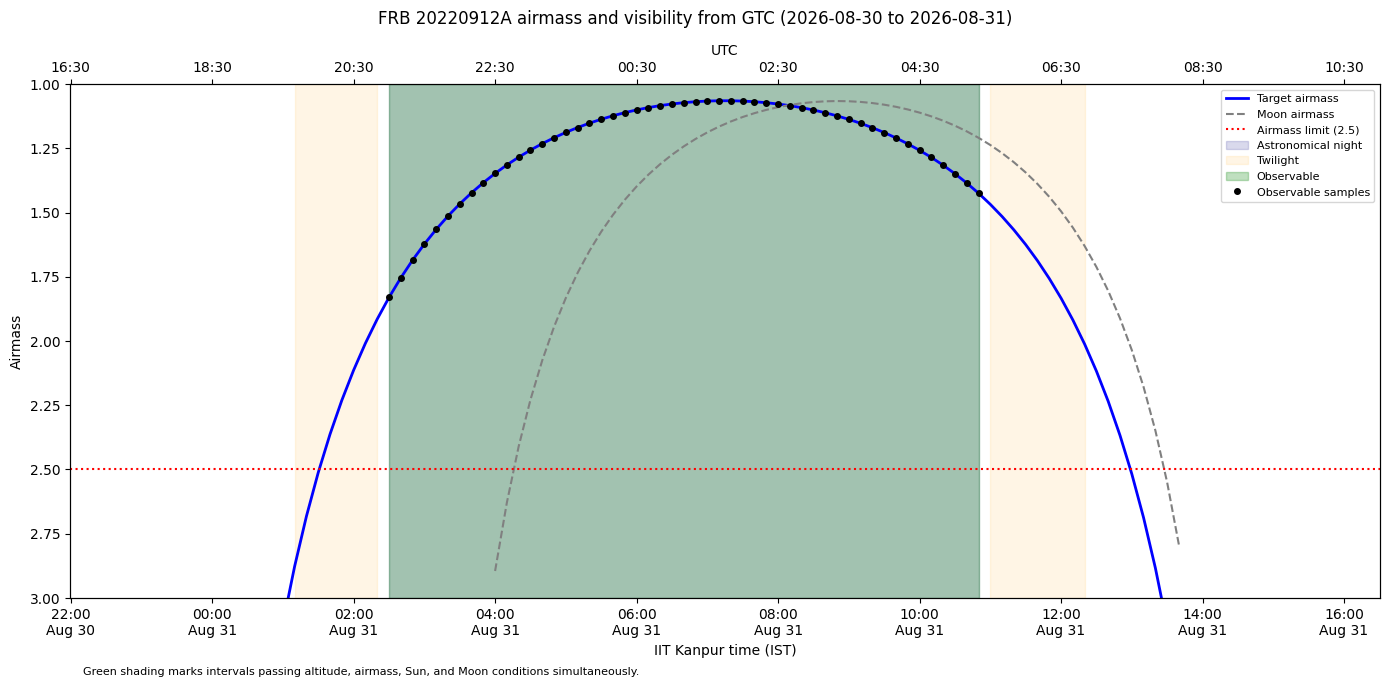

In [43]:
# YOUR ANSWER:

def stitch_windows(times, visibility_state):
    """Return list of (start_time, end_time) for each consecutive True run."""
    windows = []
    n = len(visibility_state)
    i = 0
    while i < n:
        if visibility_state[i]:
            start = i
            while i < n and visibility_state[i]:
                i += 1
            end = i - 1   # last True index in this run
            windows.append((times[start], times[end]))
        else:
            i += 1
    return windows

windows = stitch_windows(times, preferred_visibility)

for start_t, end_t in windows:
    duration = (end_t - start_t).to(u.hour)
    mask = (times >= start_t) & (times <= end_t)
    best_airmass_in_window = np.nanmin(target_airmass[mask])
    midpoint_index = np.argmin(np.abs((times - (start_t + (end_t-start_t)/2)).sec))

    print(f"Window: {format_iitk(start_t)} -> {format_iitk(end_t)}  ({format_utc(start_t)} -> {format_utc(end_t)})")
    print(f"  Duration: {duration}")
    print(f"  Best airmass: {best_airmass_in_window}")
    print(f"  Midpoint Moon label: {moon_label[midpoint_index]}")


# Figure

fig, ax1 = plt.subplots(figsize=(14, 7))

x_dates = times.to_datetime(timezone=IITK_TIMEZONE)

ax1.plot(x_dates, target_airmass, color="blue", linewidth=2, label="Target airmass")
ax1.plot(x_dates, moon_airmass, color="gray", linestyle="--", label="Moon airmass")
ax1.axhline(2.5, color="red", linestyle=":", label="Airmass limit (2.5)")

ax1.set_ylim(3, 1)   # inverted: airmass 1 (best) on top, near zenith
ax1.set_xlabel("IIT Kanpur time (IST)")
ax1.set_ylabel("Airmass")

# Astronomical night / twilight shading
ax1.fill_between(x_dates, 1, 3, where=(sun_altitude.deg <= -18), color="navy", alpha=0.15, label="Astronomical night")
ax1.fill_between(x_dates, 1, 3, where=(sun_altitude.deg > -18) & (sun_altitude.deg <= 0), color="orange", alpha=0.1, label="Twilight")

# Observable windows
ax1.fill_between(x_dates, 1, 3, where=preferred_visibility, color="green", alpha=0.25, label="Observable")
ax1.plot(np.array(x_dates)[preferred_visibility], target_airmass[preferred_visibility], "ko", markersize=4, label="Observable samples")

ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M\n%b %d", tz=IITK_TIMEZONE))
ax1.legend(loc="upper right", fontsize=8)

# Aligned UTC axis on top
ax2 = ax1.twiny()
ax2.set_xlim(ax1.get_xlim())
utc_ticks = ax1.get_xticks()
ax2.set_xticks(utc_ticks)
ax2.set_xticklabels([mdates.num2date(t, tz=timezone.utc).strftime("%H:%M") for t in utc_ticks])
ax2.set_xlabel("UTC")

fig.suptitle("FRB 20220912A airmass and visibility from GTC (2026-08-30 to 2026-08-31)")
ax1.text(0.01, -0.15, "Green shading marks intervals passing altitude, airmass, Sun, and Moon conditions simultaneously.",
         transform=ax1.transAxes, fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "frb_20220912a_gtc_airmass.png", dpi=150)
plt.show()

# Write and run your code here. Add a Markdown cell below when an explanation is requested.

# Part F. All-sky observability (2 assessed marks + 2 optional bonus marks)

The previous parts established the physical ingredients needed for an observing decision. The next questions reuse those same ideas at increasing scale: first one source on one date, then a weekly all-sky GTC visibility animation over one year.

For Q19–Q20, use the geometric/airmass GTC visibility rule developed in the notebook: the source or sky position must be above the horizon, satisfy the GTC airmass limit, and be inside astronomical night. Do not include the Moon in these questions.


## Q19. Find the GTC visibility window of the repeating FRB on one date [2 marks]

Treat FRB 20220912A as a repeating source at its fixed ICRS/J2000 position. For `2026-09-01`, calculate its visibility from GTC across the full UTC day using the same HEALPix-style visibility logic: astronomical night, target altitude above the horizon, and target airmass no larger than 2.5. Report the start and end of each contiguous visibility interval in UTC and IIT Kanpur time, together with the total visible duration in hours.

This is a **single source**, not an all-sky calculation.


In [44]:
# YOUR ANSWER:

day_start = Time("2026-09-01T00:00:00", scale="utc")
day_end = Time("2026-09-01T23:59:59", scale="utc")
day_step = 10 * u.min
n_steps = int(np.round(((day_end - day_start)/day_step).to_value(u.dimensionless_unscaled)))
day_times = day_start + np.arange(n_steps+1) * day_step

day_altaz_frame = AltAz(obstime=day_times, location=gtc_location)
day_target_altaz = frb_icrs.transform_to(day_altaz_frame)

day_airmass = day_target_altaz.secz.value.astype(float)
day_airmass[day_target_altaz.alt <= 0*u.deg] = np.nan
day_airmass[~np.isfinite(day_airmass)] = np.nan
day_airmass[day_airmass < 1] = np.nan

day_sun_altitude = get_sun(day_times).transform_to(day_altaz_frame).alt

# No Moon condition here — passing a dummy array that always satisfies moon_separation check
dummy_moon_sep = np.full(len(day_times), 999.0)

day_visibility = visibility(
    day_target_altaz.alt.deg, day_airmass, day_sun_altitude.deg, dummy_moon_sep
)

day_windows = stitch_windows(day_times, day_visibility)
total_hours = sum((end - start).to(u.hour).value for start, end in day_windows) if day_windows else 0*u.hour

for start_t, end_t in day_windows:
    print(f"{format_utc(start_t)} -> {format_utc(end_t)}   |   {format_iitk(start_t)} -> {format_iitk(end_t)}")
print("Total visible duration:", total_hours, "hours")

# Write and run your code here. Add a Markdown cell below when an explanation is requested.

Altitude condition passes: 75
Airmass condition passes: 70
Sun condition passes: 52
Moon condition passes: 145
Combined passes: 52
Any observable sample: True
2026-09-01 00:00:00 UTC -> 2026-09-01 05:20:00 UTC   |   2026-09-01 05:30:00 IST -> 2026-09-01 10:50:00 IST
2026-09-01 21:00:00 UTC -> 2026-09-02 00:00:00 UTC   |   2026-09-02 02:30:00 IST -> 2026-09-02 05:30:00 IST
Total visible duration: 8.333333333333332 hours


## Q20. Generate a one-year GTC visibility animation [2 bonus marks]

Use the same **all-sky GTC visibility** model over the next year, starting on **2026-08-30** and sampled every 7 days. With a weekly cadence, the final sample within the 365-day window is **2027-08-29**. For each date, compute the HEALPix visibility map using the same GTC astronomical-night, altitude, and airmass conditions developed earlier.

Save each weekly map as a PNG frame and combine the frames into a GIF. The animation should show how the observable sky from GTC changes through the year. Use a moderate HEALPix resolution so that the calculation is practical.

Briefly describe what changes across the animation and why the observable region changes with date.

In [45]:
# YOUR ANSWER:

# Setup
import healpy as hp
import imageio.v2 as imageio
from pathlib import Path


frames_dir = OUTPUT_DIR / "yearly_frames"
frames_dir.mkdir(exist_ok=True)

# Step 1: Building the sky grid once
nside = 16
npix = hp.nside2npix(nside)
pix_ra_deg, pix_dec_deg = hp.pix2ang(nside, np.arange(npix), lonlat=True)

sky_grid = SkyCoord(ra=pix_ra_deg*u.deg, dec=pix_dec_deg*u.deg, frame="icrs")
print("Pixels in grid:", npix)

# Step 2: Weekly dates across the year
year_start = Time("2026-08-30T00:00:00", scale="utc")
week_step = 7 * u.day
n_weeks = 53
week_dates = year_start + np.arange(n_weeks) * week_step

# Local midnight each week, in UTC — GTC is roughly UTC+0/+1, so we use 00:00 UTC as a stand-in for local night
frame_paths = []

for week_idx, obs_time in enumerate(week_dates):
    altaz_frame_week = AltAz(obstime=obs_time, location=gtc_location)

    # Step 3: Transforming the whole grid at once
    grid_altaz = sky_grid.transform_to(altaz_frame_week)

    grid_airmass = grid_altaz.secz.value.astype(float)
    grid_airmass[grid_altaz.alt <= 0*u.deg] = np.nan
    grid_airmass[~np.isfinite(grid_airmass)] = np.nan
    grid_airmass[grid_airmass < 1] = np.nan

    sun_altaz_week = get_sun(obs_time).transform_to(altaz_frame_week)
    sun_altitude_week = np.full(npix, sun_altaz_week.alt.deg)   # same Sun altitude for every pixel at this instant

    dummy_moon_sep = np.full(npix, 999.0)   # Moon condition excluded, as in Q19

    vis_map = visibility(
        grid_altaz.alt.deg,
        grid_airmass,
        sun_altitude_week,
        dummy_moon_sep,
    ).astype(float)

    # Step 4: Plotting this week as a Mollweide map
    hp.mollview(
        vis_map,
        title=f"GTC visibility — {obs_time.iso[:10]}",
        unit="Observable (1) / Not (0)",
        cmap="Greens",
        min=0, max=1,
        cbar=True,
    )
    hp.graticule()

    frame_path = frames_dir / f"week_{week_idx:02d}.png"
    plt.savefig(frame_path, dpi=100)
    plt.close()
    frame_paths.append(frame_path)

    if week_idx % 10 == 0:
        print(f"Rendered week {week_idx+1}/{n_weeks} ({obs_time.iso[:10]})")

# Step 5: Stitching the frames into a GIF
frames = [imageio.imread(p) for p in frame_paths]
gif_path = OUTPUT_DIR / "gtc_yearly_visibility.gif"
imageio.mimsave(gif_path, frames, duration=0.3)

print("Saved GIF to:", gif_path)

# Write and run your code here. Add a Markdown cell below when an explanation is requested.

Pixels in grid: 3072
Altitude condition passes: 1009
Airmass condition passes: 919
Sun condition passes: 3072
Moon condition passes: 3072
Combined passes: 919
Any observable sample: True
Rendered week 1/53 (2026-08-30)
Altitude condition passes: 1008
Airmass condition passes: 922
Sun condition passes: 3072
Moon condition passes: 3072
Combined passes: 922
Any observable sample: True
Altitude condition passes: 1011
Airmass condition passes: 919
Sun condition passes: 3072
Moon condition passes: 3072
Combined passes: 919
Any observable sample: True
Altitude condition passes: 1010
Airmass condition passes: 921
Sun condition passes: 3072
Moon condition passes: 3072
Combined passes: 921
Any observable sample: True
Altitude condition passes: 1010
Airmass condition passes: 922
Sun condition passes: 3072
Moon condition passes: 3072
Combined passes: 922
Any observable sample: True
Altitude condition passes: 1005
Airmass condition passes: 915
Sun condition passes: 3072
Moon condition passes: 3072


Rendered week 51/53 (2027-08-15)
Altitude condition passes: 1012
Airmass condition passes: 924
Sun condition passes: 3072
Moon condition passes: 3072
Combined passes: 924
Any observable sample: True
Altitude condition passes: 1009
Airmass condition passes: 923
Sun condition passes: 3072
Moon condition passes: 3072
Combined passes: 923
Any observable sample: True
Saved GIF to: assignment_outputs/gtc_yearly_visibility.gif


AI Use in the assignment: I used AI in 1. Sorting out some of the Astropy commands and 2. Structuring some code blocks, mostly in the last couple of questions.

## Submission checklist

- Restart the kernel and run every cell from top to bottom.
- Keep units attached during physical calculations.
- Use UTC internally; show IIT Kanpur time whenever reporting a civil clock time.
- Label Local Sidereal Time as LST, never IST.
- Keep the exact `visibility(altitude, airmass, sun_altitude, moon_separation)` interface.
- Confirm `assignment_outputs/frb_20220912a_gtc_airmass.png` exists and is non-empty.
- Confirm the Q20 one-year GTC GIF and its generated weekly frame PNGs are present.

## Compact glossary

- **Astropy quantity:** a numerical value stored together with a physical unit.
- **UTC:** the standard time scale used to identify an instant worldwide.
- **IST:** Indian Standard Time, the IIT Kanpur civil clock, UTC+05:30.
- **JD/MJD:** continuous astronomical day counts; MJD is JD minus 2,400,000.5.
- **ICRS:** a modern standard equatorial frame expressed with RA and Dec.
- **Galactic coordinates:** longitude $l$ and latitude $b$ referred to the Milky Way.
- **Ecliptic coordinates:** longitude $\lambda$ and latitude $\beta$ referred to Earth's orbital plane; longitude begins at the vernal equinox.
- **Angular separation:** the shortest great-circle angle between two directions on the celestial sphere.
- **Mollweide projection:** an equal-area elliptical map of the full celestial sphere; Matplotlib expects longitude and latitude in radians.
- **LST:** Local Sidereal Time, an astronomical angle determined by time and longitude.
- **Hour angle:** $H=\mathrm{LST}-\alpha$; zero at meridian transit.
- **Transit:** passage across the local meridian; usually the highest geometric altitude.
- **AltAz:** a horizon frame determined by observer location and time.
- **Zenith distance:** angular distance from the zenith, $z=90^\circ-h$.
- **Airmass:** approximate atmospheric path length relative to the zenith.
- **Astronomical darkness:** Sun altitude at or below $-18^\circ$ in this assignment.
- **Observable interval:** consecutive samples satisfying every printed condition.

- **HEALPix:** a hierarchical equal-area pixelization of the celestial sphere; each pixel can store an astronomical quantity such as visibility time.
- **Visibility time:** the amount of time a source satisfies the observing constraints during a specified interval.
- **Repeating FRB:** an FRB that can produce bursts on multiple occasions, so a future observing schedule can be planned for its fixed sky position.
